# Nama : Faiq Ghozy Erlangga
# NIM : 123140139

In [67]:
# Setup dependensi dan ploting

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window, find_peaks
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from IPython.display import display

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

C_SIGNAL  = '#0284c7'   # biru   — sinyal utama / audio
C_ALT     = '#0ea5e9'   # langit — sinyal pembanding
C_NEUTRAL = '#334155'   # slate  — audio mentah, teks netral
C_ALERT   = '#dc2626'   # merah  — cacat, batas bahaya, derau
C_GOOD    = '#059669'   # hijau  — kondisi hening / target
C_ACCENT  = '#7c3aed'   # violet — sorotan tersier
C_GOLD    = '#c5a059'   # emas   — panel Mel

print(f"numpy      : {np.__version__}")
print(f"librosa    : {librosa.__version__}")
print(f"soundfile  : {sf.__version__}")
print("\nSeluruh dependensi analisis audio berhasil dimuat!")

numpy      : 2.5.3
librosa    : 1.0.0
soundfile  : 0.14.0

Seluruh dependensi analisis audio berhasil dimuat!


---
## Perekaman Suara Berita di Depan Derau Statis

In [68]:
audio_path = 'audio_original.wav'

# Muat audio dengan sr=None agar laju sampel asli tidak ter-resample
y, sr = librosa.load(audio_path, sr=None, mono=True)
total_samples = len(y)
durasi = total_samples / sr
min_amp = float(np.min(y))
max_amp = float(np.max(y))
peak_val = max(abs(min_amp), abs(max_amp))
peak_dbfs = 20 * np.log10(peak_val) if peak_val > 0 else -120.0

print("=" * 50)
print("HASIL INSPEKSI AWAL AUDIO")
print("=" * 50)
print(f"Sumber berkas            : {audio_path}")
print(f"Laju sampel asli (fs)    : {sr} Hz")
print(f"Jumlah sampel total      : {total_samples:,} sampel")
print(f"Durasi rekaman           : {durasi:.2f} detik")
print(f"Nilai amplitudo minimum  : {min_amp:.5f}")
print(f"Nilai amplitudo maksimum : {max_amp:.5f}")
print(f"Puncak amplitudo         : {peak_dbfs:.2f} dBFS")
print("=" * 50)

# Pemutar audio
print("\nPemutar Audio Rekaman Berita + Derau Statis:")
display(ipd.Audio(y, rate=sr))

HASIL INSPEKSI AWAL AUDIO
Sumber berkas            : audio_original.wav
Laju sampel asli (fs)    : 48000 Hz
Jumlah sampel total      : 596,160 sampel
Durasi rekaman           : 12.42 detik
Nilai amplitudo minimum  : -1.00000
Nilai amplitudo maksimum : 0.99997
Puncak amplitudo         : 0.00 dBFS

Pemutar Audio Rekaman Berita + Derau Statis:


---
## Visualisasi Audio 4 Dimensi

### 1. Waveform (Amplitudo vs Waktu)

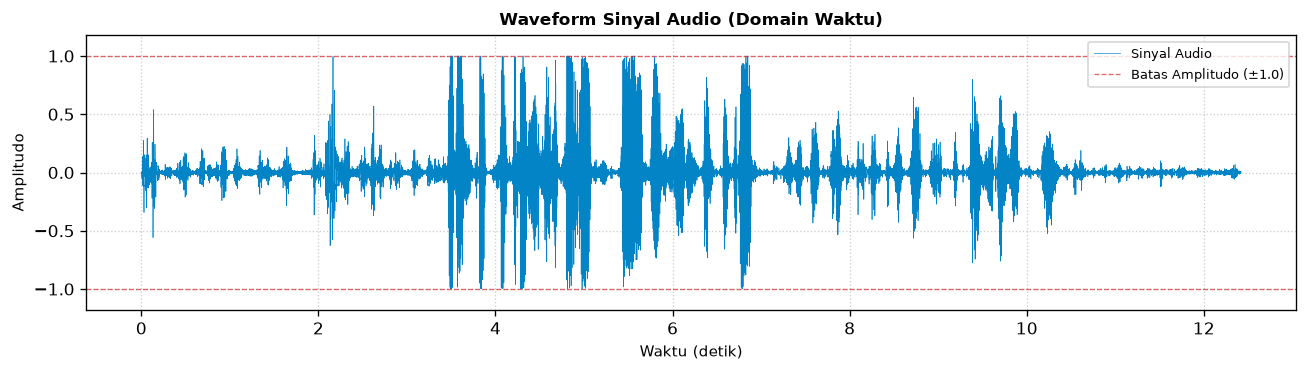

In [69]:
t = np.arange(len(y)) / sr

fig, ax = plt.subplots(figsize=(11, 3.2))

# Plot waveform sinyal audio penuh dengan batas normalisasi ±1.0
ax.plot(t, y, color=C_SIGNAL, lw=0.4, label='Sinyal Audio')
ax.axhline(1.0, color=C_ALERT, lw=0.8, linestyle='--', alpha=0.7, label='Batas Amplitudo (±1.0)')
ax.axhline(-1.0, color=C_ALERT, lw=0.8, linestyle='--', alpha=0.7)

ax.set_title("Waveform Sinyal Audio (Domain Waktu)", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.set_ylim(-1.18, 1.18)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Terlihat bahwa di detik ke 2.7 ke atas, suara vocal mulai muncul, namun sebelumnya hanyalah nada noise statis dengan beberapa pengecualian yaitu di sekitar detik 0.1 dan di detik 2.1 terjadi noice besar yang menyamai amplitudo vocal

---
### 2. Spektrum FFT

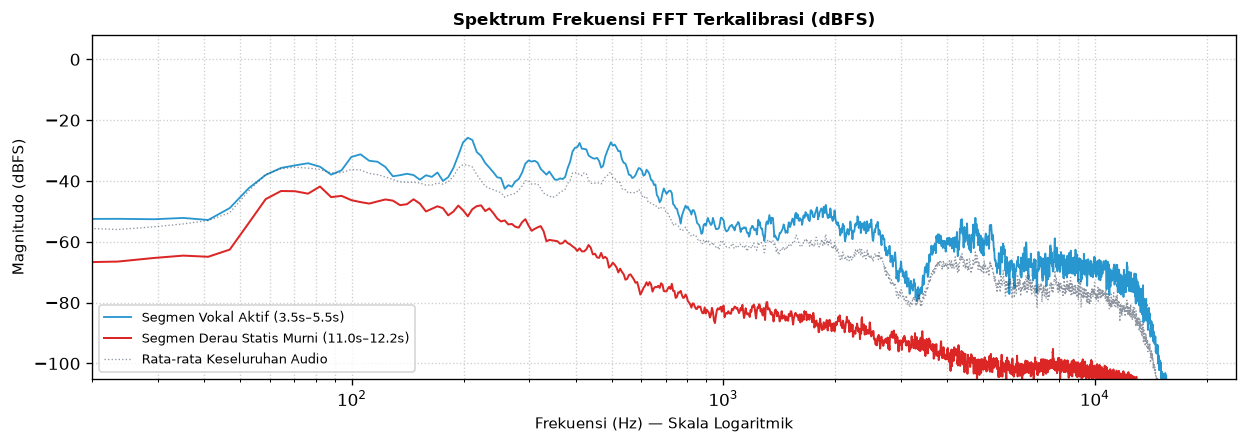

In [70]:
def spectrum_dbfs(x, sr, n_fft=8192, average=True):
    """Menghitung spektrum satu sisi berskala dBFS terkalibrasi."""
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))
    w = get_window('hann', n_fft, fftbins=True)
    hop = n_fft // 2
    n_frames = 1 + (len(x) - n_fft) // hop if average else 1
    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frames):
        seg = x[i * hop : i * hop + n_fft]
        akumulasi += np.abs(np.fft.rfft(seg * w))
    mag = akumulasi / n_frames / np.sum(w)
    mag[1:-1] *= 2.0  # koreksi satu sisi
    db = 20 * np.log10(np.maximum(mag, 1e-12))
    freqs = np.fft.rfftfreq(n_fft, 1 / sr)
    return freqs, db

N_FFT_SPEC = 8192
freqs, db_total = spectrum_dbfs(y, sr, n_fft=N_FFT_SPEC)

# Isolasi spektrum segmen hening (pure noise floor: 11.0 - 12.2s)
y_noise_seg = y[int(11.0 * sr) : int(12.2 * sr)]
_, db_noise = spectrum_dbfs(y_noise_seg, sr, n_fft=N_FFT_SPEC)

# Isolasi spektrum segmen vokal aktif (3.5 - 5.5s)
y_vocal_seg = y[int(3.5 * sr) : int(5.5 * sr)]
_, db_vocal = spectrum_dbfs(y_vocal_seg, sr, n_fft=N_FFT_SPEC)

fig, ax = plt.subplots(figsize=(10.5, 3.8))

ax.semilogx(freqs[1:], db_vocal[1:], color=C_SIGNAL, lw=1.1, alpha=0.85, label='Segmen Vokal Aktif (3.5s–5.5s)')
ax.semilogx(freqs[1:], db_noise[1:], color=C_ALERT, lw=1.2, label='Segmen Derau Statis Murni (11.0s–12.2s)')
ax.semilogx(freqs[1:], db_total[1:], color=C_NEUTRAL, lw=0.8, linestyle=':', alpha=0.55, label='Rata-rata Keseluruhan Audio')

ax.set_title("Spektrum Frekuensi FFT Terkalibrasi (dBFS)", fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — Skala Logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, sr // 2)
ax.set_ylim(-105, 8)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

Magnitudo paling besar terjadi pada frekuensi sekitar 80Hz hingga menurun pada 1kHz, perbedaan perbandingan magnitudo antara segmen vokal dan statis noise kurang lebih 1/3

---
### 3. Spektrogram STFT

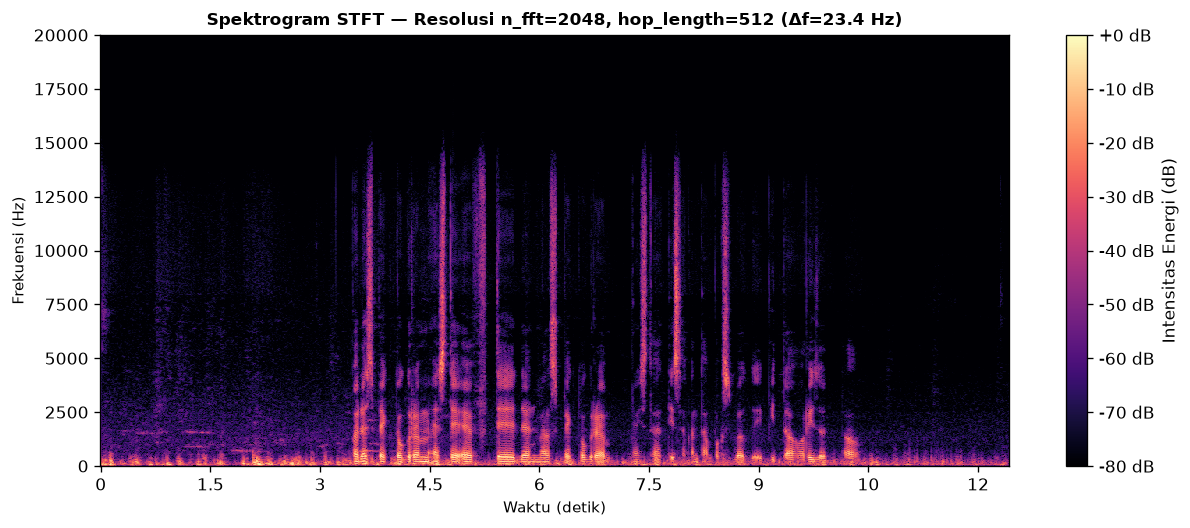

In [71]:
N_FFT = 2048
HOP = 512

S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
S_db = librosa.amplitude_to_db(S, ref=np.max)

fig, ax = plt.subplots(figsize=(10.5, 4.5))
img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                               x_axis='time', y_axis='linear', ax=ax, cmap='magma')
ax.set_ylim(0, 20000)  # Rentang pengamatan fokus vokal & derau (0 - 5 kHz)
ax.set_title(f"Spektrogram STFT — Resolusi n_fft={N_FFT}, hop_length={HOP} (Δf={sr/N_FFT:.1f} Hz)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi (Hz)", fontsize=9)
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Intensitas Energi (dB)')


plt.tight_layout()
plt.show()

Terlihat energi kekuningan yang selalu ada di sepanjang waktu yang umumnya adalah noise, lalu muncul ada beberapa energi yang menyeluruh di seluruh frekuensi hingga kurang lebih 15kHz yang menandakan vocal 

---
### 4. Mel-Spektrogram (Skala Perseptual)

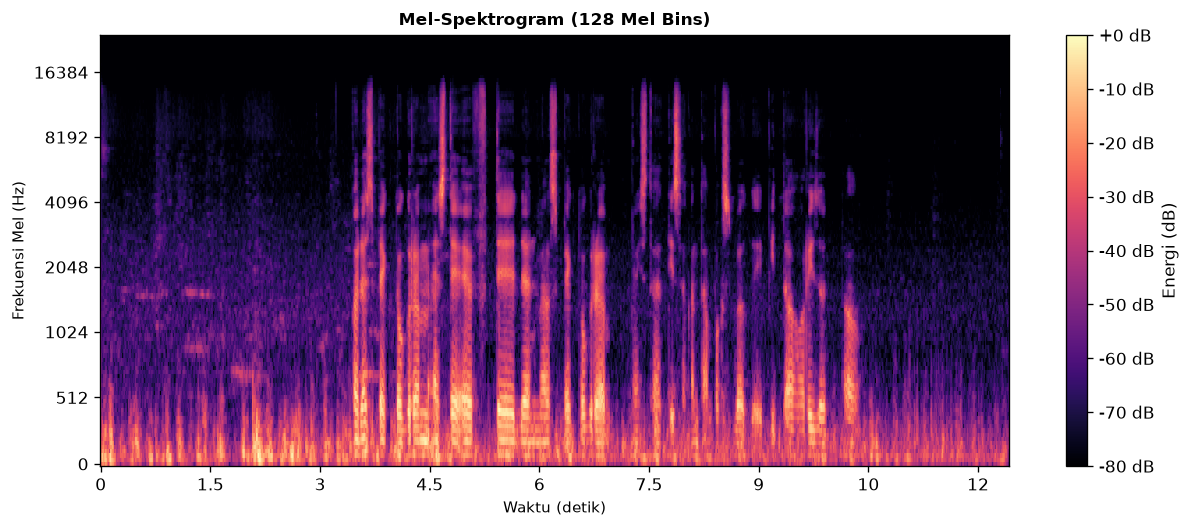

In [72]:
N_MELS = 128

# Hitung Mel-spektrogram (power=2.0 bawaan, dikonversi dengan power_to_db)
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, ax = plt.subplots(figsize=(10.5, 4.5))
img_mel = librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                                   x_axis='time', y_axis='mel', ax=ax, cmap='magma')

ax.set_title(f"Mel-Spektrogram ({N_MELS} Mel Bins)", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi Mel (Hz)", fontsize=9)
fig.colorbar(img_mel, ax=ax, format='%+2.0f dB', label='Energi (dB)')

plt.tight_layout()
plt.show()

Dari yang saya amati dan pelajari, Mel Spektogram ini skalanya lebih di arahkan ke vokal manusia sehingga lebih memperjelas bagian di bawah 5kHz dibanding STFT

---
---
---
## Eksperimen Resampling & Pembuktian Aliasing

In [73]:
import scipy.signal as signal
# Parameter Downsampling (48 kHz -> 8 kHz, M = 6)
M_down = 6
fs_target = sr // M_down  # 8000 Hz
nyquist_new = fs_target / 2  # 4000 Hz
# Skenario A: Naive Decimation (tanpa filter anti-aliasing)
y_naive = y[::M_down]
# Skenario B: Resampling Standar Polyphase FIR (dilindungi filter anti-aliasing)
y_clean = signal.resample_poly(y, up=1, down=M_down)

print("\nSkenario A — Downsampling Naif (Aliasing Tanpa Filter):")
display(ipd.Audio(y_naive, rate=fs_target))
print("\nSkenario B — Resampling Standar Polyphase FIR (Dengan Filter Anti-Aliasing):")
display(ipd.Audio(y_clean, rate=fs_target))

sf.write('audio_downsampled_naive.wav', y_naive, fs_target)
sf.write('audio_downsampled_clean.wav', y_clean, fs_target)



Skenario A — Downsampling Naif (Aliasing Tanpa Filter):



Skenario B — Resampling Standar Polyphase FIR (Dengan Filter Anti-Aliasing):


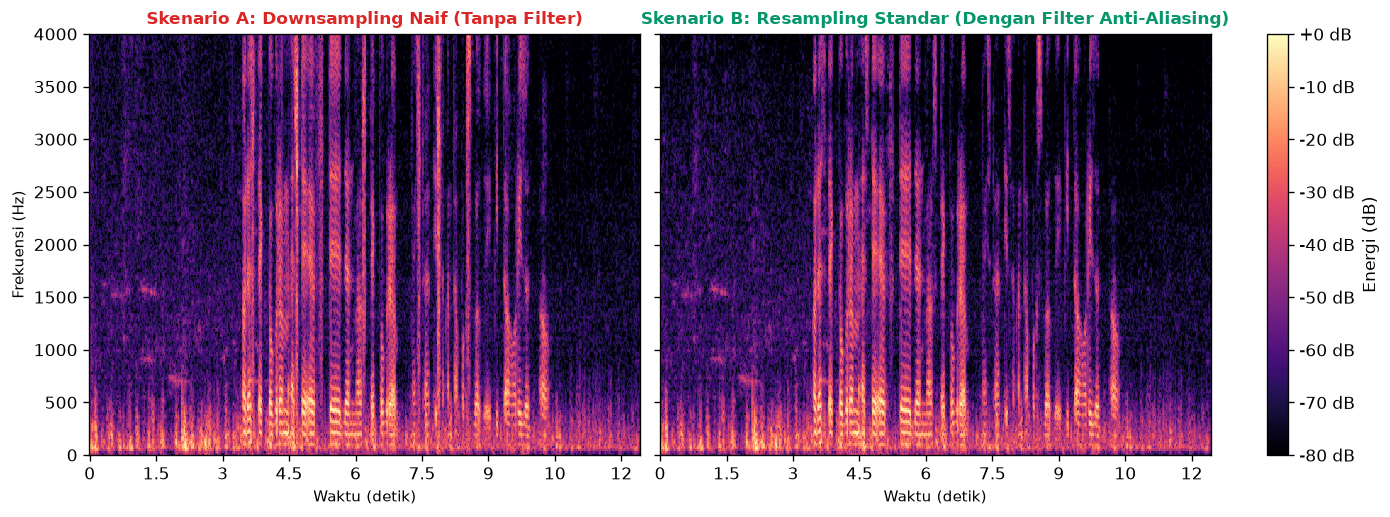

In [74]:
# Perhitungan STFT untuk kedua skenario pada laju sampel 8.000 Hz
N_FFT_DOWN = 512
HOP_DOWN = 128

S_naive = np.abs(librosa.stft(y_naive, n_fft=N_FFT_DOWN, hop_length=HOP_DOWN))
S_naive_db = librosa.amplitude_to_db(S_naive, ref=np.max)

S_clean = np.abs(librosa.stft(y_clean, n_fft=N_FFT_DOWN, hop_length=HOP_DOWN))
S_clean_db = librosa.amplitude_to_db(S_clean, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True, constrained_layout=True)

# 1. Spektrogram Skenario A (Desimasi Naif)
img0 = librosa.display.specshow(S_naive_db, sr=fs_target, hop_length=HOP_DOWN, n_fft=N_FFT_DOWN,
                                x_axis='time', y_axis='hz', ax=axes[0], cmap='magma')
axes[0].set_title("Skenario A: Downsampling Naif (Tanpa Filter)", fontsize=10, fontweight='bold', color=C_ALERT)
axes[0].set_xlabel("Waktu (detik)", fontsize=9)
axes[0].set_ylabel("Frekuensi (Hz)", fontsize=9)
axes[0].set_ylim(0, nyquist_new)
axes[0].axhline(nyquist_new, color=C_ALERT, lw=1.0, linestyle='--')

# 2. Spektrogram Skenario B (Resampling Standar Polyphase FIR)
img1 = librosa.display.specshow(S_clean_db, sr=fs_target, hop_length=HOP_DOWN, n_fft=N_FFT_DOWN,
                                x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_title("Skenario B: Resampling Standar (Dengan Filter Anti-Aliasing)", fontsize=10, fontweight='bold', color=C_GOOD)
axes[1].set_xlabel("Waktu (detik)", fontsize=9)
axes[1].set_ylabel("")
axes[1].set_ylim(0, nyquist_new)
axes[1].axhline(nyquist_new, color=C_GOOD, lw=1.0, linestyle='--')

fig.colorbar(img1, ax=axes, format='%+2.0f dB', label='Energi (dB)')

plt.show()

Sejujurnya, hampir tidak terdengar perbedaan antara kedua skenario, ini mungkin disebabkan karena suara noise dengan frekuensi di bawah 4kHz yang bercampur dengan vocal